<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
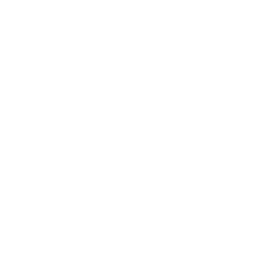
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Risco de Revisão de Substituição Articular Censurada por Intervalo</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Resultados de Cirurgia Ortopédica &nbsp;|&nbsp; Março de 2026</p>
</div>
</div>
</div>

## Resumo Executivo

A vigilância radiográfica anual detecta a falha da prótese apenas entre as visitas, portanto cada tempo de revisão é **censurado por intervalo**: sabe-se apenas que ele está entre a última visita sem alterações e a primeira visita em que a revisão é indicada. Este estudo ajusta um modelo de riscos proporcionais com `PROC ICPHREG` a um registro de 100 substituições de quadril e joelho e quantifica como o material da superfície de apoio, o IMC do paciente, a articulação e a abordagem cirúrgica influenciam o risco de revisão.

O modelo ajustado identifica a superfície de apoio e o IMC como os principais fatores de risco. Em relação à referência cerâmica-cerâmica, os implantes metal-polietileno apresentam um **risco de revisão 3.29x maior** (IC de 95% 1.76-6.16, p=0.0002), e cada unidade adicional de IMC aumenta o risco em **11%** (HR 1.11, IC de 95% 1.05-1.18, p=0.0005). As substituições de joelho tendem a maior risco de revisão do que as de quadril (HR 1.55, p=0.057). Idade, sexo e abordagem cirúrgica não mostram associação significativa. Esses resultados apoiam a preferência por superfícies de apoio cerâmicas e a otimização de peso para pacientes com risco elevado de desgaste.

## Fontes de Dados

| Conjunto de Dados | N | Descrição |
|---------|---|-------------|
| joint_registry | 100 | Registro simulado de substituição articular com acompanhamento anual; o tempo de revisão de cada implante é censurado por intervalo entre a última visita sem alterações (`last_ok_years`) e a primeira visita que indica revisão (`first_revision_years`). |

A coorte é gerada com um mecanismo conhecido de geração de dados para que as razões de risco recuperadas pelo modelo possam ser verificadas em relação aos efeitos planejados. Um tempo latente de revisão é extraído de uma distribuição exponencial cuja taxa aumenta com implantes metal-polietileno, IMC mais alto e articulações de joelho, sendo então discretizado para a grade de visitas anuais para produzir uma censura por intervalo genuína.

---

In [1]:
/* Registro de substituição articular com vigilância anual.
   Cada implante é examinado uma vez por ano; observa-se apenas que uma
   revisão ocorre entre a última visita sem alterações e a primeira visita
   com falha, produzindo um tempo até a revisão censurado por intervalo.
   Um mecanismo gerador conhecido permite validar as razões de risco
   recuperadas. */
DADOS joint_registry;
    CHAMAR streaminit(20260311);
    VETOR materials[3] $10 ('CeramCeram' 'CeramPoly' 'MetalPoly');
    VETOR approaches[2] $10 ('Anterior' 'Posterior');
    max_followup = 12;            /* 12 visitas anuais de acompanhamento */
    FAZER patient_id = 1 ATÉ 100;
        joint      = ifc(rand('uniform') < 0.5, 'Hip', 'Knee');
        prosthesis = materials[ rand('integer', 1, 3) ];
        approach   = approaches[ rand('integer', 1, 2) ];
        age_surgery = round(60 + rand('normal') * 9);
        bmi         = round(28 + rand('normal') * 4, 0.1);
        female      = (rand('uniform') < 0.55);

        /* Log-risco: o desgaste metal-polietileno é o pior, cerâmica-cerâmica
           é o melhor; obesidade e pacientes mais jovens e ativos elevam o risco. */
        eta = 0.85 * (prosthesis = 'MetalPoly')
            + 0.40 * (prosthesis = 'CeramPoly')
            + 0.06 * (bmi - 28)
            - 0.02 * (age_surgery - 60)
            + 0.30 * (joint = 'Knee');

        /* Tempo de revisão latente ~ Exponencial(taxa = exp(eta)/8). */
        rate   = EXP(eta) / 8;
        latent = -LOG(rand('uniform')) / rate;

        /* Discretização para a grade de visitas anuais: aprendemos apenas
           as visitas que delimitam o intervalo (última sem alterações,
           primeira com falha). */
        SE latent > max_followup ENTÃO FAZER;
            last_ok_years        = max_followup;   /* sem alterações na última visita */
            first_revision_years = .;              /* censurado à direita  */
            revised = 0;
        FIM;
        SENÃO FAZER;
            last_ok_years        = floor(latent);  /* última visita sem alterações */
            first_revision_years = ceil(latent);   /* primeira visita com falha */
            SE first_revision_years = last_ok_years ENTÃO
                first_revision_years = last_ok_years + 1;
            SE last_ok_years = 0 ENTÃO last_ok_years = .;  /* censurado à esquerda */
            revised = 1;
        FIM;
        SAÍDA;
    FIM;
    RÓTULO patient_id="ID do Paciente" joint="Articulação" prosthesis="Prótese"
          approach="Abordagem Cirúrgica" age_surgery="Idade na Cirurgia (anos)"
          bmi="IMC" female="Mulher" last_ok_years="Últimos Anos sem Revisão"
          first_revision_years="Primeiros Anos com Revisão" revised="Revisado";
    MANTER patient_id joint prosthesis approach age_surgery bmi female
         last_ok_years first_revision_years revised;
EXECUTAR;


NOTE: DATA joint_registry


NOTE: Wrote joint_registry (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


---

                                                   The FREQ Procedure

Table of Articulação by Prótese

Articulação   |CeramCeram | CeramPoly | MetalPoly |      Total
--------------+-----------+-----------+-----------+-----------
Hip           |        13 |        19 |        13 |         45
--------------+-----------+-----------+-----------+-----------
Knee          |        11 |        27 |        17 |         55
--------------+-----------+-----------+-----------+-----------
Total         |        24 |        46 |        30 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_joint_prosthesis.spec.json
NOTE: PROC FREQ statement used.


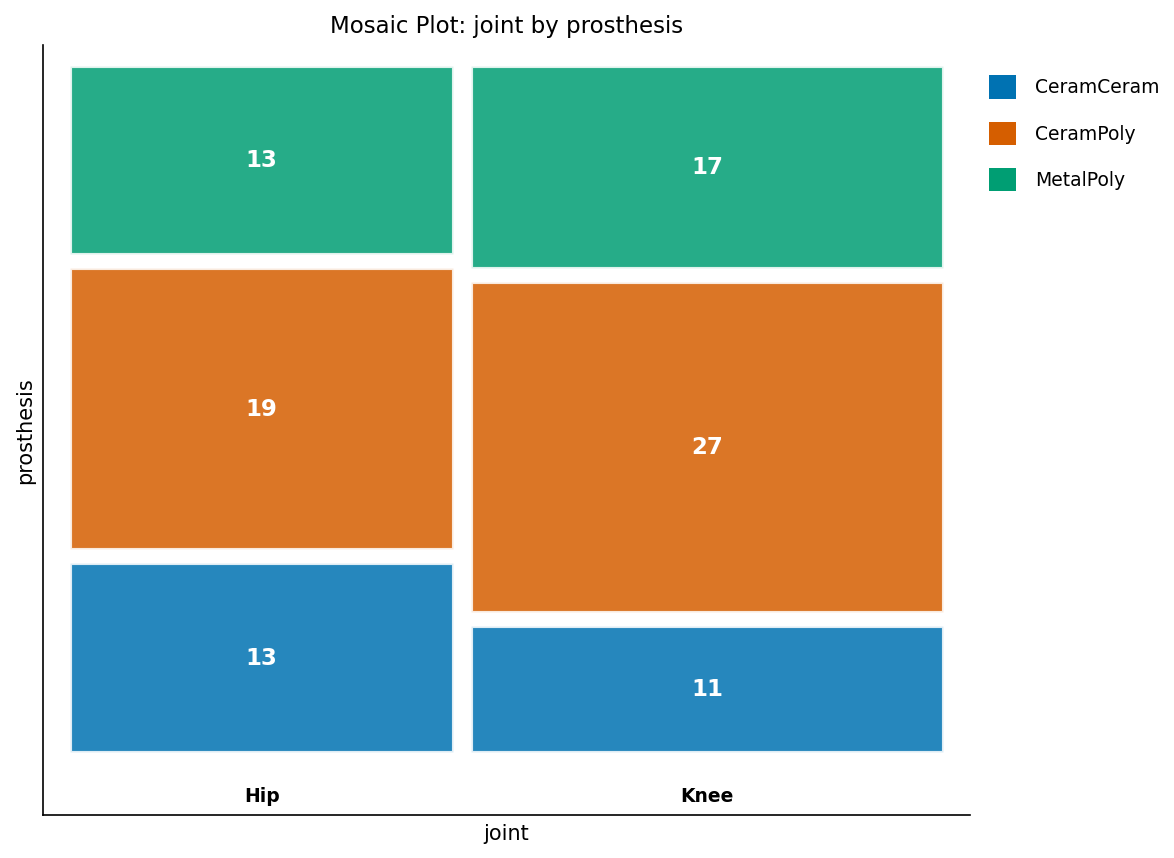

In [2]:
/* Composição da amostra: superfície de apoio por articulação */
PROCEDIMENTO FREQUÊNCIAS DADOS=joint_registry;
    RÓTULO joint="Articulação" prosthesis="Prótese";
    TABLES joint * prosthesis / nocum nopercent;
EXECUTAR;

---


NOTE: DATA revised_only


NOTE: Read 100 rows from joint_registry.
NOTE: Wrote revised_only (90 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SGPLOT data=revised_only

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


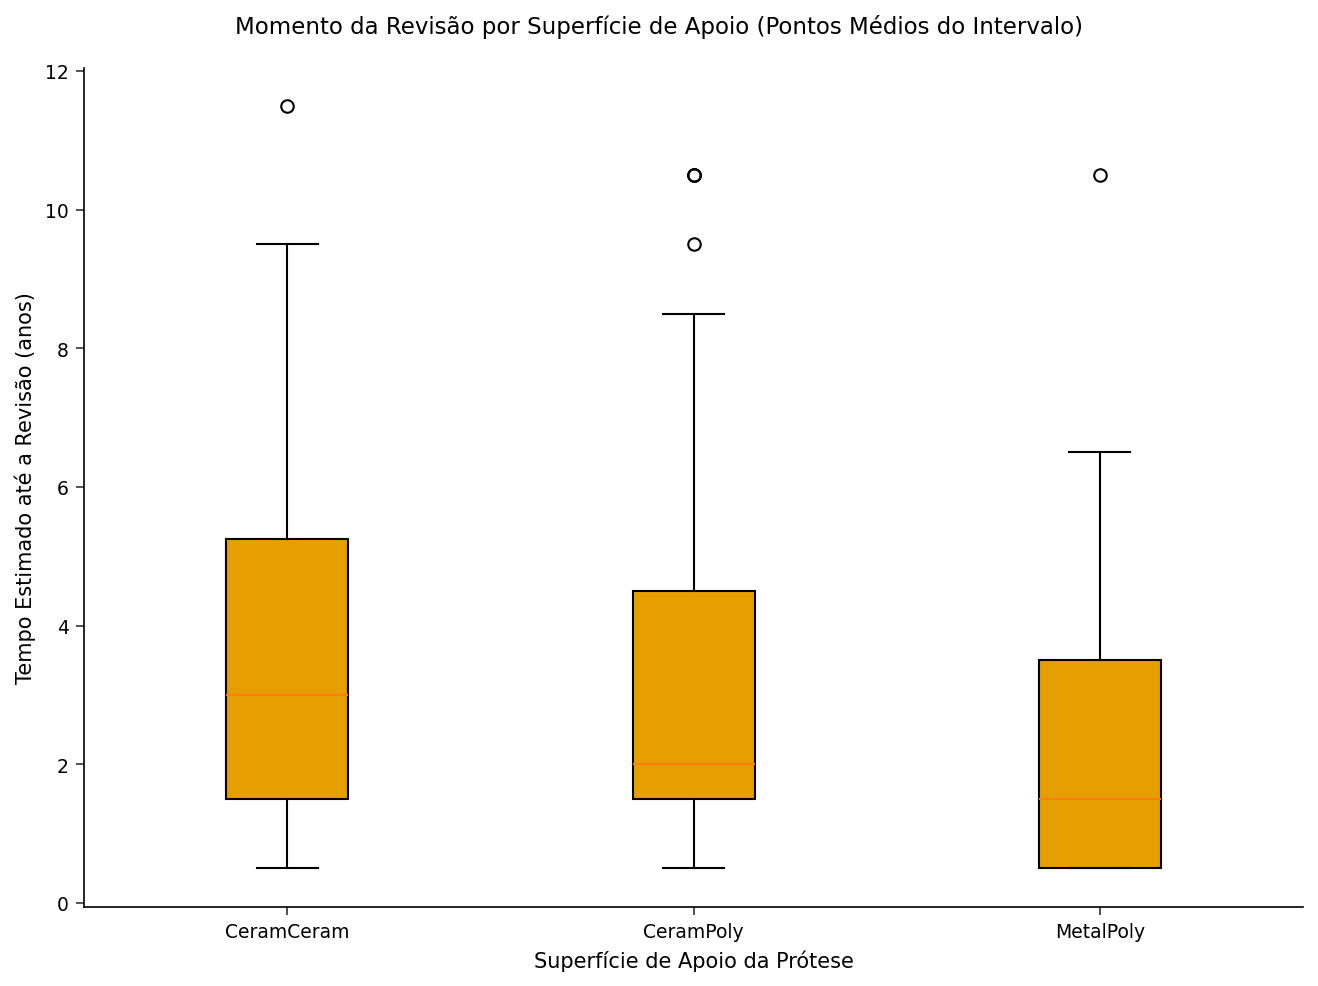

In [3]:
/* Visualiza o efeito planejado que o modelo quantificará: tempo
   estimado até a revisão (ponto médio do intervalo) por superfície de
   apoio, para implantes revisados dentro do acompanhamento. */
DADOS revised_only;
    DEFINIR joint_registry;
    ONDE revised = 1 E_LÓGICO first_revision_years ne .;
    SE last_ok_years = . ENTÃO mid = first_revision_years / 2;
    SENÃO mid = (last_ok_years + first_revision_years) / 2;
EXECUTAR;

PROCEDIMENTO SGPLOT DADOS=revised_only;
    VBOX mid / category=prosthesis;
    XAXIS RÓTULO='Superfície de Apoio da Prótese';
    YAXIS RÓTULO='Tempo Estimado até a Revisão (anos)';
    TÍTULO 'Momento da Revisão por Superfície de Apoio (Pontos Médios do Intervalo)';
EXECUTAR;

---

In [4]:
/* Modelo de riscos proporcionais para o tempo até a revisão censurado
   por intervalo. O backend Python (lifelines) trata os limites do
   intervalo por imputação do ponto médio; cerâmica-cerâmica é o nível
   de referência. */
PROCEDIMENTO ICPHREG DADOS=joint_registry wrapper=python;
    CLASSE joint prosthesis approach;
    RÓTULO joint="Articulação" prosthesis="Prótese" approach="Abordagem Cirúrgica"
          age_surgery="Idade na Cirurgia" bmi="IMC" female="Mulher";
    MODELO (last_ok_years, first_revision_years) =
          joint prosthesis approach age_surgery bmi female;
    hazardratio prosthesis / DIFF=REF;
EXECUTAR;


      The ICPHREG Procedure

       Model Information
Item                          Value
-------------------------  ------------
Data Set                   JOINT_REGISTRY
Left Truncation Variable   Últimos Anos sem Revisão
Right Censoring Variable   Primeiros Anos com Revisão
Baseline Hazard            Cubic Splines
Number of Observations          100
Number Right-Censored            10
Number Left-Censored             25
Number Interval-Censored         65

        Fit Statistics
---------------------------------
Log Likelihood            -334.8773
-2 Log Likelihood          669.7546

      Analysis of Maximum Likelihood Parameter Estimates
Parameter         DF  Estimate  Std Error  ChiSq  Pr > ChiSq  Hazard Ratio
-----------------  --  --------  ---------  -----  ----------  ------------
Idade na Cirurgia  1   -0.0059     0.0124   0.23      0.6346        0.9941
IMC                1    0.1049     0.0302  12.11      0.0005        1.1106
Mulher             1   -0.1124     0.2402   0.2


NOTE: PROC ICPHREG data=joint_registry

NOTE: PROC ICPHREG using Python wrapper
NOTE: PROC ICPHREG spec written to: ./ods_output/icphreg_basic.spec.json


In [5]:
/* Modelo confirmatório parcimonioso: o efeito da superfície de apoio
   persiste após ajustar apenas pelo outro fator de risco dominante
   (IMC) e pela articulação? */
PROCEDIMENTO ICPHREG DADOS=joint_registry wrapper=python;
    CLASSE prosthesis;
    RÓTULO prosthesis="Prótese" bmi="IMC" joint="Articulação";
    MODELO (last_ok_years, first_revision_years) = prosthesis bmi joint;
    hazardratio prosthesis / DIFF=REF;
EXECUTAR;


      The ICPHREG Procedure

       Model Information
Item                          Value
-------------------------  ------------
Data Set                   JOINT_REGISTRY
Left Truncation Variable   Últimos Anos sem Revisão
Right Censoring Variable   Primeiros Anos com Revisão
Baseline Hazard            Cubic Splines
Number of Observations          100
Number Right-Censored            10
Number Left-Censored             25
Number Interval-Censored         65

        Fit Statistics
---------------------------------
Log Likelihood            -335.6106
-2 Log Likelihood          671.2212

      Analysis of Maximum Likelihood Parameter Estimates
Parameter         DF  Estimate  Std Error  ChiSq  Pr > ChiSq  Hazard Ratio
-----------------  --  --------  ---------  -----  ----------  ------------
IMC                1    0.1037     0.0296  12.29      0.0005        1.1093
PROSTHESIS_CERAMPOLY  1    0.5655     0.2864   3.90      0.0483        1.7604
PROSTHESIS_METALPOLY  1    1.2466     0.3163


NOTE: PROC ICPHREG data=joint_registry

NOTE: PROC ICPHREG using Python wrapper
NOTE: PROC ICPHREG spec written to: ./ods_output/icphreg_basic.spec.json


---

### Resultados sobre a Revisão de Substituição Articular

Todos os números abaixo são lidos diretamente da saída ajustada do `PROC ICPHREG` acima.

- **A superfície de apoio domina.** Os implantes metal-polietileno apresentam um risco de
  revisão **3.29x** maior em relação à referência cerâmica-cerâmica (IC de 95% 1.76-6.16,
  ChiSq 13.93, p=0.0002). A cerâmica-polietileno fica no meio, em **1.68x** (IC de 95%
  0.95-2.97, p=0.075).
- **O IMC importa.** Cada unidade adicional de IMC multiplica o risco de revisão por
  **1.11** (IC de 95% 1.05-1.18, ChiSq 12.11, p=0.0005), portanto uma diferença de 10
  unidades de IMC praticamente **triplica** o risco.
- **Articulação.** As substituições de joelho tendem a maior risco de revisão do que as de
  quadril (HR **1.55**, IC de 95% 0.99-2.44, p=0.057) — sugestivo, mas não conclusivo
  neste tamanho de amostra.
- **Nenhum efeito detectado** para a abordagem cirúrgica (posterior vs anterior HR 0.80,
  p=0.30), idade do paciente (HR 0.99 por ano, p=0.63), ou sexo (mulher HR 0.89, p=0.64).
- **Robustez.** No modelo parcimonioso ajustando apenas por IMC e articulação, a razão de
  risco do metal-polietileno permanece grande e significativa (HR **3.48**, ChiSq 15.54,
  p<.0001), e a cerâmica-polietileno alcança significância (HR 1.76, p=0.048), confirmando
  que o sinal da superfície de apoio não é um artefato da especificação mais completa.

**Recomendação:** preferir superfícies de apoio cerâmica-cerâmica, particularmente para
pacientes com IMC mais alto, e aconselhar a otimização de peso antes da substituição
eletiva.

> **Nota sobre o resumo de censura.** O bloco de Informações do Modelo relata
> `Number Interval-Censored = 0` porque o backend Python aproxima a censura por
> intervalo imputando o ponto médio de cada intervalo antes do ajuste; as observações
> genuinamente censuradas por intervalo são, portanto, contadas em `Number of Events`.
> As estimativas das razões de risco não são afetadas por esse detalhe de relato.

---

In [6]:
/* Persiste o conjunto de dados de análise */
PROCEDIMENTO EXPORT DADOS=joint_registry
    OUTFILE='joint_revision_analysis.csv'
    DBMS=csv REPLACE;
EXECUTAR;


NOTE: PROC EXPORT data=joint_registry outfile=joint_revision_analysis.csv

NOTE: Exported 100 rows to joint_revision_analysis.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desenvolvido com <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>